# Dipole error study

In [1]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import healpy as hp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad

from iminuit import Minuit
from iminuit.cost import LeastSquares

from Simulation.simulMap import *

# Set random seed for reproducibility
#np.random.seed(42)

# 1) Galaxy Generation functions

In [2]:
def proba_schechter_mag(M, M_star, alpha):
    """Compute the relative probability of a magnitude M.
    M_star is the caracteristic magnitude of Schechter's luminosity function."""
    L_ratio = 10**(0.4 * (M_star - M)) #Conversion magnitude -> relative luminosity L/L*
    return (L_ratio**alpha) * np.exp(-L_ratio)

def generate_schechter_magnitudes(N, M_min=-23, M_max=-15, M_star=-20.44, alpha=-1.1):
    """Generate N randomized absolute magnitudes, by using a reject test and Schechter's law."""
    magnitudes = []
    while len(magnitudes) < N:
        M_test = np.random.uniform(M_min, M_max)
        p_test = np.random.uniform(0, 1) #Probability for rejet test
        if p_test < proba_schechter_mag(M_test, M_star, alpha): magnitudes.append(M_test)         
    return np.array(magnitudes)

def get_dL(zi, H0=67.4, Om=0.315, Ol=0.685, c=3e8):
    '''Compute the luminosity distance depending on the redshift z, the Hubble constant H0, the cosmological parameters Om and Ol, and the speed of ligt c.'''
    inv_Ez = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + Ol)
    integral, _ = quad(inv_Ez, 0, zi)
    return (c / H0) * (1 + zi) * integral

In [3]:
def generate_galaxies(N, z_min=0.01, z_max=1.0, M_min=-23, M_max=-15, M_star=-20.44, alpha=-1.1, sigma_M_star=1.5, rejectTest_M=False, only_coord=False, **kwargs):
    #Cosmological Parameters  (Planck 2018):
    H0 = kwargs.get('H0', 67.4)
    Om = kwargs.get('Om', 0.315)
    Ol = kwargs.get('Ol', 0.685)
    c = kwargs.get('c', 3e5) #speed of ligt in km/s (because H0 is in Km/s/Mpc)
    M_sun = kwargs.get('M_sun', 4.83) #Absolute magnitude of Sun

    #Coord ra, dec, z:
    ra = np.random.uniform(0, 360, N)
    dec = np.random.uniform(-1, 1, N)
    dec = np.degrees(np.arcsin(dec))
    z = np.random.uniform(z_min, z_max, N) #Redshift
    if only_coord: return ra, dec, z

    #Other data:
    dL_mpc = np.array([get_dL(zi, H0, Om, Ol, c) for zi in z]) #luminosity distance in Mpc
    #Absolute magnitudes:
    if rejectTest_M: M = generate_schechter_magnitudes(N, M_min, M_max, M_star, alpha)
    else: M = np.random.normal(M_star, sigma_M_star, N)
    m = M + 5*np.log10(dL_mpc) + 25 #Aparent magnitudes
    L = 10**(0.4 * (M_sun - M)) #luminosities
    return ra, dec, z, m, M, L, dL_mpc

## Test ```generate_galaxies``` function:

Number of pixels = 49152


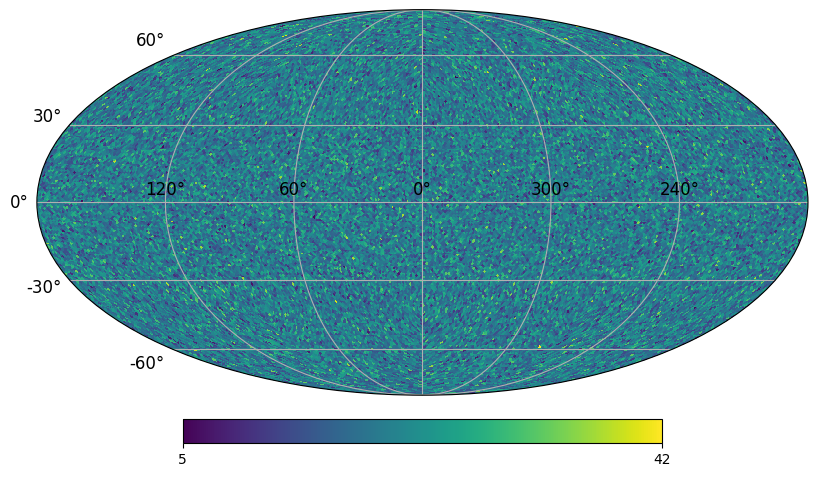

In [4]:
nest=False
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)
print("Number of pixels = {}".format(NPIX))
NSources = int(1e6)

ra, dec, z = generate_galaxies(NSources, only_coord=True)
Nsources_px = RADEC2NSource(NSIDE, ra, dec, nest=nest)
hp.projview(Nsources_px, graticule=True, graticule_labels=True, nest=nest);

# 2) Testing ```hp.fit_dipole``` function

In [5]:
#list of moopoles and dipoles generated:
monop_list = []
dip_list = []

#Map generation:
Nrandom = 1000 #nb. of maps generated
for i in range(Nrandom):
    if i%100 == 0: print("i =", i)
    ra, dec, z = generate_galaxies(NSources, only_coord=True)
    map = RADEC2NSource(NSIDE, ra, dec, nest=nest) #map of nb. of sources by pixel
    monop, dip = hp.fit_dipole(map, nest=nest)
    monop_list.append(monop)
    dip_list.append(dip)
monop_list, dip_list = np.array(monop_list), np.array(dip_list)

#min et max:
monop_imin, monop_imax = np.argmin(monop_list), np.argmax(monop_list)
dip_imin, dip_imax = np.argmin(np.linalg.norm(dip_list, axis=1)), np.argmax(np.argmin(np.linalg.norm(dip_list, axis=1)))

#Error computation and stats:
print("Monopole = {} +- {}".format(np.mean(monop_list), np.std(monop_list)))
print("Monopole min = {}\nMonopole max = {}".format(monop_list[monop_imin], monop_list[monop_imax]))

print("\nDipole = {} +- {}".format(np.mean(dip_list, axis=0), np.std(dip_list, axis=0)))
print("Dipole norm = {} +- {}".format(np.linalg.norm(np.mean(dip_list, axis=0)), np.linalg.norm(np.std(dip_list, axis=0))))
print("Dipole norm mean = {} +- {}".format(np.mean(np.linalg.norm(dip_list, axis=1)), np.std(np.linalg.norm(dip_list, axis=1))))
print("Dipole norm min = {}\nDipole norm max = {}".format(np.linalg.norm(dip_list[dip_imin]), np.linalg.norm(dip_list[dip_imax])))

i = 0
i = 100
i = 200
i = 300
i = 400
i = 500
i = 600
i = 700
i = 800
i = 900
Monopole = 20.345052083333332 +- 0.0
Monopole min = 20.345052083333332
Monopole max = 20.345052083333332

Dipole = [ 0.00024564  0.00020921 -0.00012665] +- [0.03562621 0.03530243 0.03646483]
Dipole norm = 0.00034662126039111793 +- 0.06200945118933311
Dipole norm mean = 0.05737819502310237 +- 0.023516694474166107
Dipole norm min = 0.004221179610963939
Dipole norm max = 0.031238433789864253


## Fitting dipole norm histogramm

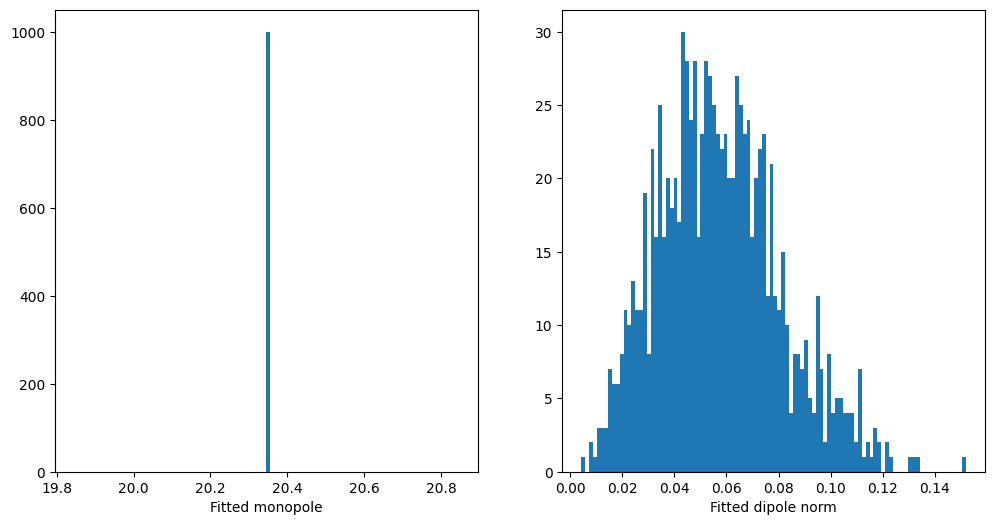

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
var_monop, bins_monop = get_hist(monop_list, xlabel='Fitted monopole', bins=100, figax=(fig, ax[0]), show=False)
var_dip, bins_dip = get_hist(np.linalg.norm(dip_list, axis=1), xlabel='Fitted dipole norm', bins=100, figax=(fig, ax[1]));

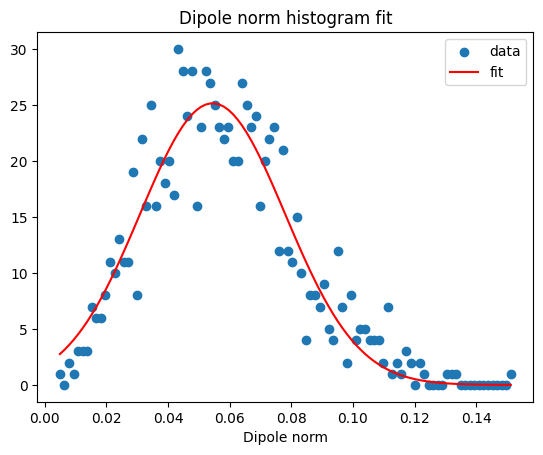

In [7]:
m = fit_minuit(bins_dip, var_dip, 0.5, gauss, (2, 0.05, np.sqrt(0.05)), ("A", "mu", "sigma"),
              title="Dipole norm histogram fit", xlabel="Dipole norm")

In [8]:
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3409 (χ²/ndof = 35.1)      │              Nfcn = 179              │
│ EDM = 1.64e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A     │   1.484   │   0.007   │   -0.007   │   0.007    │         │         │       │
│ 1 │ mu    │ 54.47e-3  │  0.13e-3  │  -0.13e-3  │  0.13e-3   │         │         │       │
│ 2 │ sigma │ 23.54e-3  │  0.13e-3  │  -0.13e-3  │  0.13e-3   │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.007   │   0.007   │ -0.13e-3  │  0.13e-3  │ -0.13e-3  │  0.13e-3  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───────┬────────────────────────────┐
│       │        A       mu    sigma │
├───────┼────────────────────────────┤
│     A │ 4.83e-05 0.024e-6 0.546e-6 │
│    mu │ 0.024e-6 1.58e-08 0.001e-6 │
│ sigma │ 0.546e-6 0.001e-6 1.71e-08 │
└───────┴────────────────────────────┘

## Fitting dipole coords histogramm

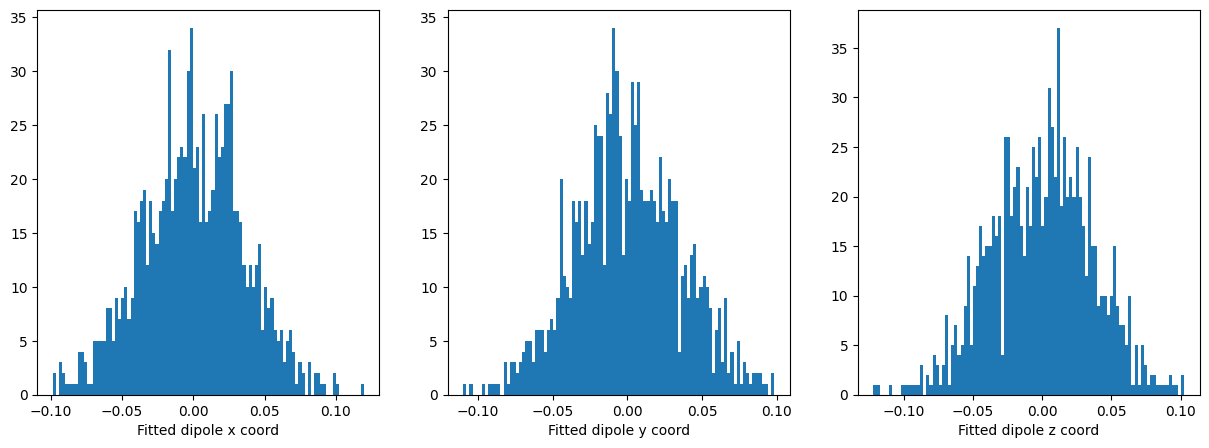

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
coord = ["x", "y", "z"]
var_dip_coord, bins_dip_coord = [], []
for i in range(3):
    var_dip_i, bins_dip_i = get_hist(dip_list[:,i], title='', xlabel='Fitted dipole {} coord'.format(coord[i]), bins=100, figax=(fig, ax[i]), show=False) #show=False because show=True would interrupt the loop; in the note book, the figure is showed anyway
    var_dip_coord.append(var_dip_i)
    bins_dip_coord.append(bins_dip_i)

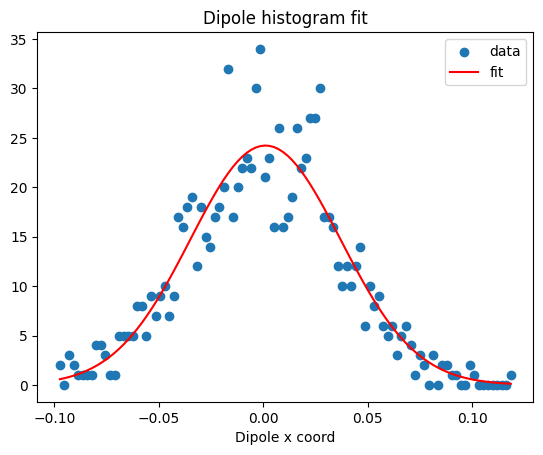

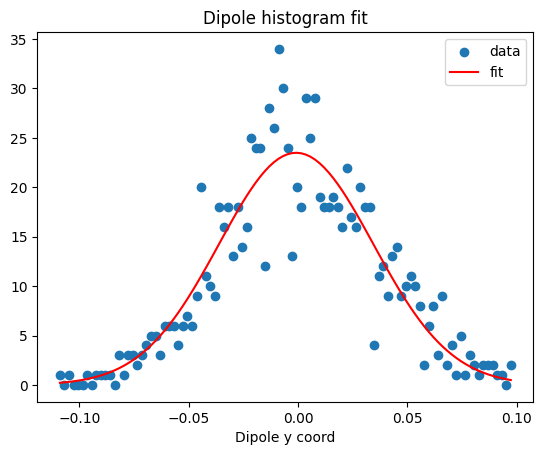

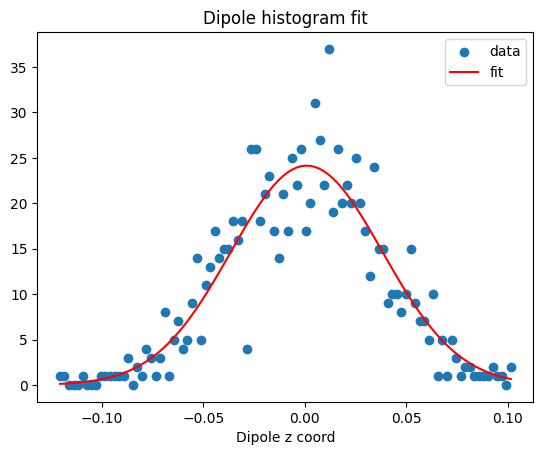

In [10]:
m = []
#init = [(30, 0, 0.05), (30, 0, 0.05), (30, 0.05, np.sqrt(0.05))]
for i in range(3):
    mi = fit_minuit(bins_dip_coord[i], var_dip_coord[i], 0.5, gauss, (30, 0, 0.05), ("A", "mu", "sigma"),
              title="Dipole histogram fit", xlabel="Dipole {} coord".format(coord[i]))
    m.append(mi)

In [11]:
print("For x coord:")
m[0]

For x coord:


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3990 (χ²/ndof = 41.1)      │              Nfcn = 247              │
│ EDM = 8.17e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A     │   2.187   │   0.010   │   -0.010   │   0.010    │         │         │       │
│ 1 │ mu    │  1.04e-3  │  0.19e-3  │  -0.19e-3  │  0.20e-3   │         │         │       │
│ 2 │ sigma │ 36.02e-3  │  0.19e-3  │  -0.19e-3  │  0.19e-3   │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.01   │   0.01    │ -0.19e-3  │  0.20e-3  │ -0.19e-3  │  0.19e-3  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───────┬────────────────────────────┐
│       │        A       mu    sigma │
├───────┼────────────────────────────┤
│     A │ 0.000104 -0.06e-6  1.14e-6 │
│    mu │ -0.06e-6 3.79e-08       -0 │
│ sigma │  1.14e-6       -0 3.76e-08 │
└───────┴────────────────────────────┘

In [12]:
print("For y coord:")
m[1]

For y coord:


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4533 (χ²/ndof = 46.7)      │              Nfcn = 256              │
│ EDM = 1.48e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A     │   2.077   │   0.010   │   -0.010   │   0.010    │         │         │       │
│ 1 │ mu    │ -0.89e-3  │  0.19e-3  │  -0.19e-3  │  0.19e-3   │         │         │       │
│ 2 │ sigma │ 35.28e-3  │  0.20e-3  │  -0.20e-3  │  0.20e-3   │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.01   │   0.01    │ -0.19e-3  │  0.19e-3  │  -0.2e-3  │  0.2e-3   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───────┬────────────────────────────┐
│       │        A       mu    sigma │
├───────┼────────────────────────────┤
│     A │ 9.94e-05  0.08e-6  1.17e-6 │
│    mu │  0.08e-6 3.78e-08        0 │
│ sigma │  1.17e-6        0 3.96e-08 │
└───────┴────────────────────────────┘

In [13]:
print("For z coord:")
m[2]

For z coord:


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4851 (χ²/ndof = 50.0)      │              Nfcn = 208              │
│ EDM = 1.56e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A     │   2.262   │   0.011   │   -0.011   │   0.010    │         │         │       │
│ 1 │ mu    │  0.97e-3  │  0.20e-3  │  -0.20e-3  │  0.20e-3   │         │         │       │
│ 2 │ sigma │ 37.38e-3  │  0.20e-3  │  -0.20e-3  │  0.20e-3   │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.011   │   0.010   │  -0.2e-3  │  0.2e-3   │  -0.2e-3  │  0.2e-3   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───────┬────────────────────────────┐
│       │        A       mu    sigma │
├───────┼────────────────────────────┤
│     A │  0.00011 -0.06e-6  1.19e-6 │
│    mu │ -0.06e-6 4.07e-08       -0 │
│ sigma │  1.19e-6       -0 3.91e-08 │
└───────┴────────────────────────────┘

In [14]:
hp.fit_dipole?

Signature: hp.fit_dipole(m, nest=False, bad=-1.6375e+30, gal_cut=0)
Docstring:
Fit a dipole and a monopole to the map, excluding bad pixels.

Parameters
----------
m : float, array-like
  the map to which a dipole is fitted and subtracted, accepts masked maps
nest : bool
  if ``False`` m is assumed in RING scheme, otherwise map is NESTED
bad : float
  bad values of pixel, default to :const:`UNSEEN`.
gal_cut : float [degrees]
  pixels at latitude in [-gal_cut;+gal_cut] degrees are not taken into account

Returns
-------
res : tuple of length 2
  the monopole value in res[0] and the dipole vector (as array) in res[1]

See Also
--------
remove_dipole, fit_monopole, remove_monopole
File:      ~/miniconda3/envs/M2Stage/lib/python3.10/site-packages/healpy/pixelfunc.py
Type:      function